# VAE

In [68]:
# Import required packages
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models
import numpy as np
from tqdm import tqdm
from dataset_utils import get_data_loaders
from hyperparams import dataset, batch_size, device

## Hyperparams

In [69]:
latent_dim = 256 if dataset == "cifar100" else 1024
lr = 5e-4
num_epochs = 10
kl_weight = 1 if dataset == "cifar100" else 8
save_figures = True

## VAE Structure

In [70]:
class ConvVAE(nn.Module):
    def __init__(self, img_size=32, latent_dim=256):
        super().__init__()
        self.img_size = img_size
        self.latent_dim = latent_dim

        # ---------- Encoder ----------
        self.enc = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),  # -> img/2
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1),# -> img/4
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# -> img/8
            nn.ReLU(),
            nn.Conv2d(256, 512, 4, 2, 1),# -> img/16
            nn.ReLU()
        )

        feat_dim = (img_size // 16)
        feat_dim = feat_dim * feat_dim * 512

        self.mu = nn.Linear(feat_dim, latent_dim)
        self.logvar = nn.Linear(feat_dim, latent_dim)

        # ---------- Decoder ----------
        self.fc_dec = nn.Linear(latent_dim, feat_dim)

        self.dec = nn.Sequential(
            nn.ConvTranspose2d(512, 256, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.enc(x)
        h = h.view(h.size(0), -1)
        mu = self.mu(h)
        logvar = self.logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = (0.5 * logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_dec(z)
        h = h.view(h.size(0), 512, self.img_size//16, self.img_size//16)
        return self.dec(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_rec = self.decode(z)
        return x_rec, mu, logvar, z

In [71]:
def reconstruction_loss(x, x_hat):
    return F.mse_loss(x_hat, x, reduction="mean")

def kl_divergence(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    recon_loss = reconstruction_loss(x, x_hat)
    kld = kl_divergence(mu, logvar) 

    total_loss = recon_loss + beta * kld
    return total_loss, recon_loss, kld    

### Define optimizer and start training.

In [72]:
model = ConvVAE(img_size=32, latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loader, _ = get_data_loaders(dataset=dataset)

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    total_recon = 0
    total_kld = 0

    for x, y in tqdm(train_loader, leave=False):
        x = x.to(device)

        x_hat, mu, logvar, z = model(x)

        loss, recon, kld = vae_loss(x, x_hat, mu, logvar, beta=kl_weight)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kld += kld.item()

    print(f"Epoch {epoch+1}/{num_epochs} "
          f"Loss={total_loss/len(train_loader):.4f} "
          f"Recon={total_recon/len(train_loader):.4f} "
          f"KLD={total_kld/len(train_loader):.4f}")


Epoch 1/10 Loss=1.2067 Recon=1.1867 KLD=0.0200


Epoch 2/10 Loss=1.1299 Recon=1.0929 KLD=0.0370


Epoch 3/10 Loss=1.1123 Recon=1.0767 KLD=0.0355


Epoch 4/10 Loss=1.1040 Recon=1.0672 KLD=0.0368


Epoch 5/10 Loss=1.0923 Recon=1.0547 KLD=0.0376


Epoch 6/10 Loss=1.0843 Recon=1.0460 KLD=0.0383


Epoch 7/10 Loss=1.0793 Recon=1.0405 KLD=0.0388


Epoch 8/10 Loss=1.0753 Recon=1.0360 KLD=0.0393


Epoch 9/10 Loss=1.0728 Recon=1.0325 KLD=0.0402


Epoch 10/10 Loss=1.0652 Recon=1.0219 KLD=0.0433


In [76]:
import random
import torch

def encode_images(x):
    model.eval()
    with torch.no_grad():
        mu, logvar = model.encode(x.to(device))
    return mu  # use mu for distances

# --------------------------
# Distance between two images
# --------------------------
def latent_distance(x1, x2):
    z1 = encode_images(x1)   
    z2 = encode_images(x2)
    return torch.norm(z1 - z2, p=2).item()


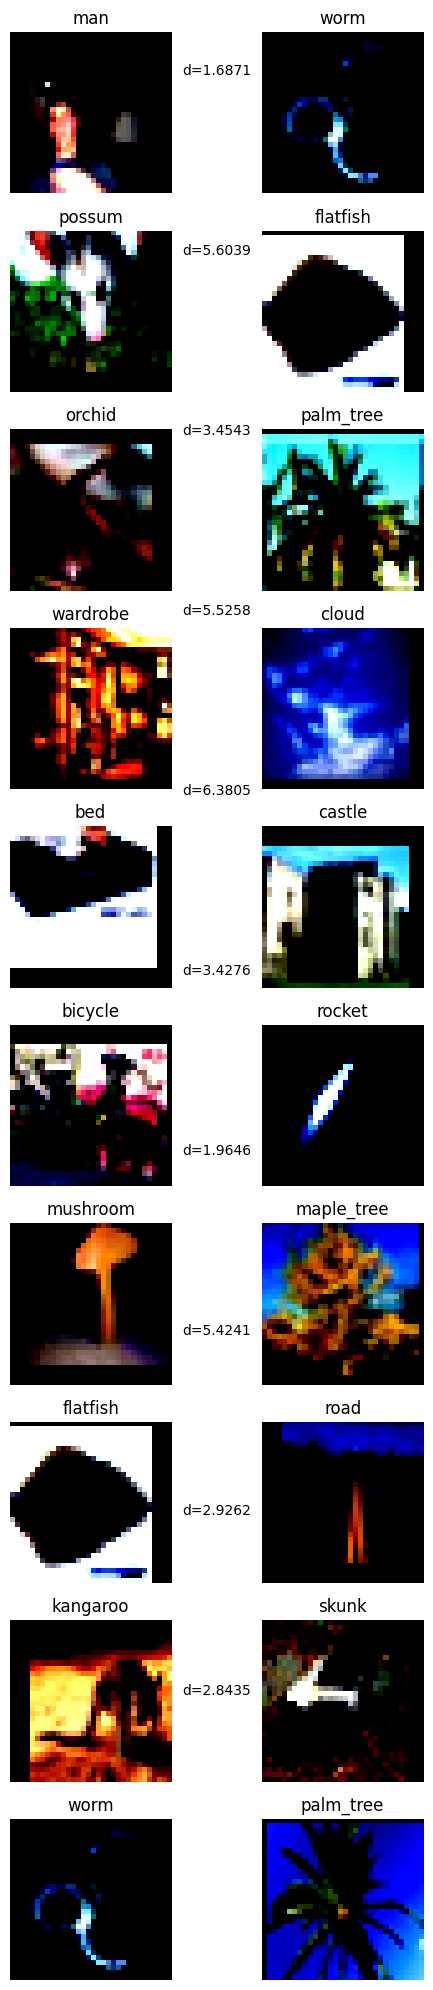

In [81]:
import torch
import random
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

class_names = train_loader.dataset.classes
num_samples = images.size(0)

plt.figure(figsize=(6, 20))

for i in range(10):
    idx1, idx2 = random.sample(range(num_samples), 2)

    img1 = images[idx1]
    img2 = images[idx2]

    label1 = labels[idx1].item()
    label2 = labels[idx2].item()

    dist = latent_distance(img1.unsqueeze(0), img2.unsqueeze(0))

    # left image
    ax1 = plt.subplot(10, 2, 2*i + 1)
    ax1.imshow(img1.detach().cpu().permute(1, 2, 0).clamp(0, 1))
    ax1.axis("off")
    ax1.set_title(f"{class_names[label1]}")

    # right image
    ax2 = plt.subplot(10, 2, 2*i + 2)
    ax2.imshow(img2.detach().cpu().permute(1, 2, 0).clamp(0, 1))
    ax2.axis("off")
    ax2.set_title(f"{class_names[label2]}")

    # ---- distance label centered between the two ----
    plt.figtext(
        0.5,                           # center horizontal
        0.96 - i * 0.09,               # vertical row position
        f"d={dist:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()


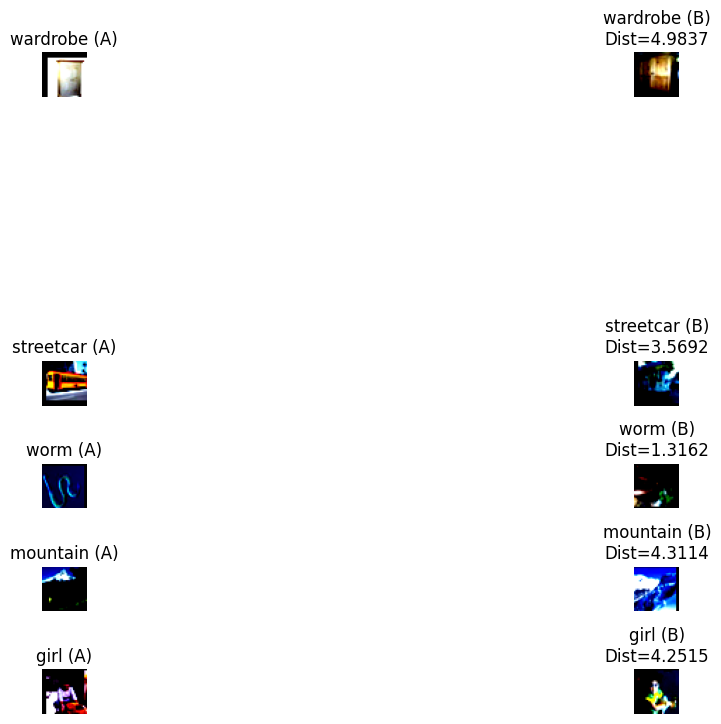

In [ ]:
import random
import matplotlib.pyplot as plt

model.eval()

images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

class_names = train_loader.dataset.classes

unique_classes = labels.unique().tolist()
chosen_classes = random.sample(unique_classes, 10)

plt.figure(figsize=(12, 10))

for i, c in enumerate(chosen_classes):
    # get indices for this class
    idxs = (labels == c).nonzero(as_tuple=True)[0].tolist()

    if len(idxs) < 2:
        continue  # skip rare classes just in case

    idx1, idx2 = random.sample(idxs, 2)

    img1 = images[idx1]
    img2 = images[idx2]

    dist = latent_distance(img1.unsqueeze(0), img2.unsqueeze(0))

    ax1 = plt.subplot(10, 2, 2*i + 1)
    ax2 = plt.subplot(10, 2, 2*i + 2)

    ax1.imshow(img1.detach().cpu().permute(1, 2, 0).clamp(0, 1))
    ax2.imshow(img2.detach().cpu().permute(1, 2, 0).clamp(0, 1))

    ax1.axis("off")
    ax2.axis("off")

    class_name = class_names[int(c)]
    ax1.set_title(f"{class_name} (A)")
    ax2.set_title(f"{class_name} (B)\nDist={dist:.4f}")

plt.tight_layout()
plt.show()
